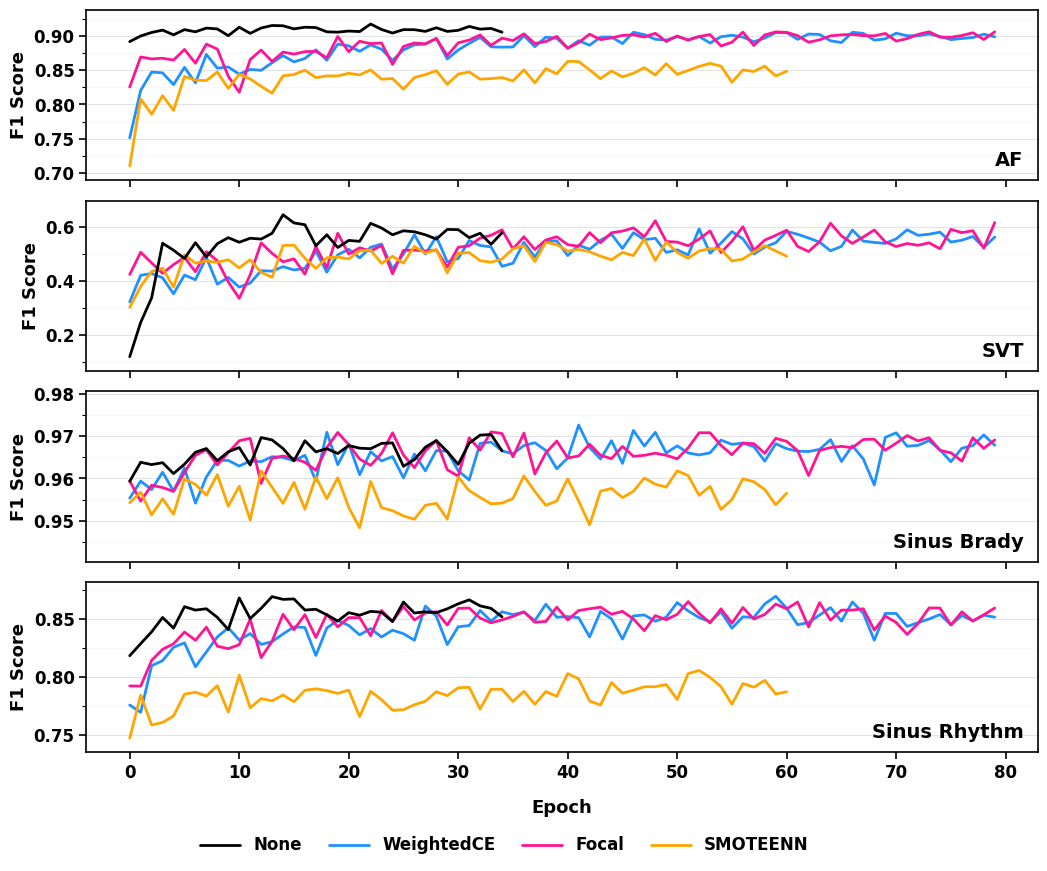

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

df = pd.read_csv(
    r"C:\Projects\DeepLearningProject\plotting\a1_per_class_training_histories.csv",
    keep_default_na=False
)

df.columns = df.columns.str.strip()
df["Imbalance_Method"] = (
    df["Imbalance_Method"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", "", regex=True)
)

plot_order = ["WeightedCE", "Focal", "SMOTEENN", "None"]
legend_order = ["None", "WeightedCE", "Focal", "SMOTEENN"]

# Colorblind-safe palette
colors = {
        "None": "#000000",
        "WeightedCE": "dodgerblue",
        "Focal": "deeppink",
        "SMOTEENN": "orange",
}

line_widths = {
    "None": 2,
    "WeightedCE": 2,
    "Focal": 2,
    "SMOTEENN": 2
}

zorders = {
    "WeightedCE": 2,
    "Focal": 3,
    "SMOTEENN": 4,
    "None": 5
}

required_methods = set(legend_order)
present_methods = set(df["Imbalance_Method"].dropna().unique())
missing_methods = required_methods - present_methods
if missing_methods:
    raise ValueError(f"Missing methods in CSV: {sorted(missing_methods)}")

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 13,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.linewidth": 1.2,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)

classes = [
    ("AF_F1", "AF"),
    ("SVT_F1", "SVT"),
    ("Sinus Brady_F1", "Sinus Brady"),
    ("Sinus Rhythm_F1", "Sinus Rhythm")
]

for ax, (col, panel_label) in zip(axes, classes):
    vals = []

    for method in plot_order:
        sub = (
            df.loc[df["Imbalance_Method"] == method, ["Epoch", col]]
            .copy()
            .sort_values("Epoch")
        )

        if sub.empty:
            raise ValueError(f"No rows found for method={method}, column={col}")

        x = pd.to_numeric(sub["Epoch"], errors="coerce").to_numpy()
        y = pd.to_numeric(sub[col], errors="coerce").to_numpy()

        mask = (~pd.isna(x)) & (~pd.isna(y))
        x = x[mask]
        y = y[mask]

        if len(x) == 0:
            raise ValueError(f"No numeric data found for method={method}, column={col}")

        vals.extend(y.tolist())

        ax.plot(
            x,
            y,
            color=colors[method],
            linewidth=line_widths[method],
            solid_capstyle="round",
            label=method,
            zorder=zorders[method]
        )

    ymin = min(vals)
    ymax = max(vals)
    yrange = ymax - ymin
    pad = max(0.008, yrange * 0.10)

    ax.set_ylim(ymin - pad, ymax + pad)
    ax.set_ylabel("F1 Score")

    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(axis="y", which="major", linestyle="-", linewidth=0.8, alpha=0.35)
    ax.grid(axis="y", which="minor", linestyle="--", linewidth=0.55, alpha=0.16)

    ax.tick_params(axis="both", which="major", width=1.2, length=5)
    ax.tick_params(axis="y", which="minor", width=0.8, length=3)

    ax.text(
        0.985, 0.06, panel_label,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=14,
        fontweight="bold"
    )

axes[-1].set_xlabel("Epoch", fontweight="bold", labelpad=12)
axes[-1].xaxis.set_major_locator(MultipleLocator(10))

handle_map = {line.get_label(): line for line in axes[0].lines}
handles = [handle_map[name] for name in legend_order]

fig.legend(
    handles,
    legend_order,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.03),
    handlelength=2.4,
    columnspacing=1.6
)

plt.subplots_adjust(left=0.12, right=0.985, top=0.985, bottom=0.16, hspace=0.12)

plt.savefig(
    r"C:\Projects\DeepLearningProject\plotting\f1_publication.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.06
)

plt.show()

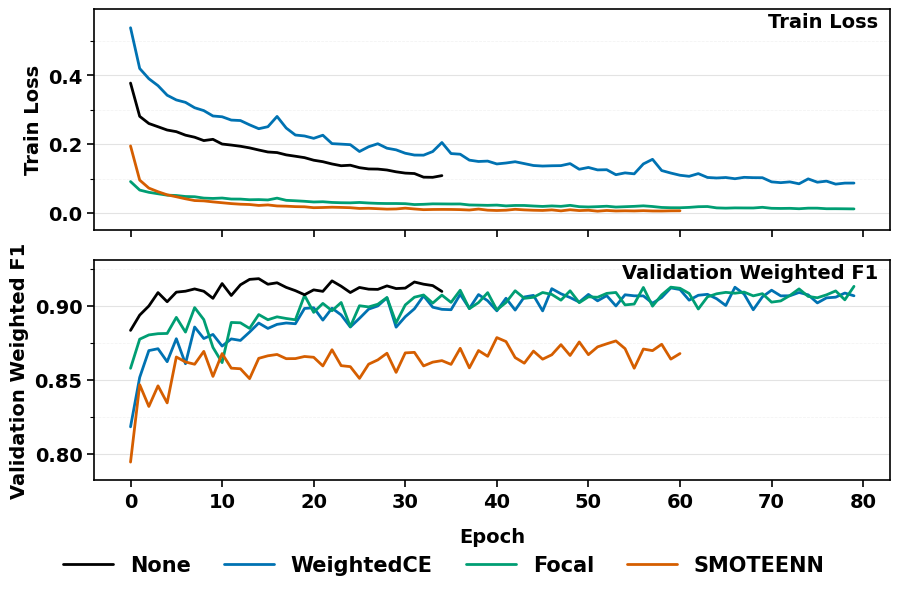

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

df = pd.read_csv(
    r"C:\Projects\DeepLearningProject\plotting\a1_overall_training_histories.csv",
    keep_default_na=False
)

df.columns = df.columns.str.strip()
df["Imbalance_Method"] = (
    df["Imbalance_Method"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", "", regex=True)
)

plot_order = ["WeightedCE", "Focal", "SMOTEENN", "None"]
legend_order = ["None", "WeightedCE", "Focal", "SMOTEENN"]

colors = {
    "None": "#000000",
    "WeightedCE": "#0072B2",
    "Focal": "#009E73",
    "SMOTEENN": "#D55E00"
}

line_widths = {
    "None": 2,
    "WeightedCE": 2,
    "Focal": 2,
    "SMOTEENN": 2
}

zorders = {
    "WeightedCE": 2,
    "Focal": 3,
    "SMOTEENN": 4,
    "None": 5
}

required_methods = set(legend_order)
present_methods = set(df["Imbalance_Method"].dropna().unique())
missing_methods = required_methods - present_methods
if missing_methods:
    raise ValueError(f"Missing methods in CSV: {sorted(missing_methods)}")

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 14,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.linewidth": 1.2,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

fig, axes = plt.subplots(2, 1, figsize=(9.2, 6), sharex=True)

panels = [
    ("Train_Loss", "Train Loss"),
    ("Validation_Weighted_F1", "Validation Weighted F1")
]

for ax, (col, panel_label) in zip(axes, panels):
    vals = []

    for method in plot_order:
        sub = (
            df.loc[df["Imbalance_Method"] == method, ["Epoch", col]]
            .copy()
            .sort_values("Epoch")
        )

        if sub.empty:
            raise ValueError(f"No rows found for method={method}, column={col}")

        x = pd.to_numeric(sub["Epoch"], errors="coerce").to_numpy()
        y = pd.to_numeric(sub[col], errors="coerce").to_numpy()

        mask = (~pd.isna(x)) & (~pd.isna(y))
        x = x[mask]
        y = y[mask]

        if len(x) == 0:
            raise ValueError(f"No numeric data found for method={method}, column={col}")

        vals.extend(y.tolist())

        ax.plot(
            x,
            y,
            color=colors[method],
            linewidth=line_widths[method],
            solid_capstyle="round",
            label=method,
            zorder=zorders[method]
        )

    ymin = min(vals)
    ymax = max(vals)
    yrange = ymax - ymin
    pad = max(0.008, yrange * 0.10)

    ax.set_ylim(ymin - pad, ymax + pad)
    ax.set_ylabel(panel_label)

    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(axis="y", which="major", linestyle="-", linewidth=0.8, alpha=0.35)
    ax.grid(axis="y", which="minor", linestyle="--", linewidth=0.55, alpha=0.16)

    ax.tick_params(axis="both", which="major", width=1.2, length=5)
    ax.tick_params(axis="y", which="minor", width=0.8, length=3)

    ax.text(
        0.985, 0.90, panel_label,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=14,
        fontweight="bold"
    )

axes[-1].set_xlabel("Epoch", fontweight="bold", labelpad=12)
axes[-1].xaxis.set_major_locator(MultipleLocator(10))

handle_map = {line.get_label(): line for line in axes[0].lines}
handles = [handle_map[name] for name in legend_order]

fig.legend(
    handles,
    legend_order,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.01),
    handlelength=2.4,
    columnspacing=1.6,
    fontsize=15

)

plt.subplots_adjust(left=0.12, right=0.985, top=0.985, bottom=0.20, hspace=0.14)

plt.savefig(
    r"C:\Projects\DeepLearningProject\plotting\overall_training_histories.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.06
)

plt.show()

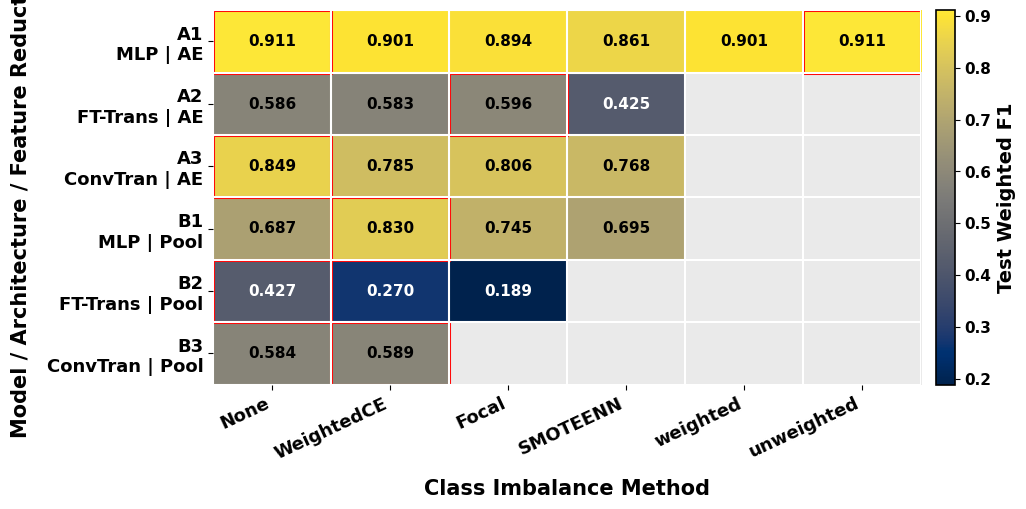

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

df = pd.read_csv(
    r"C:\Projects\DeepLearningProject\plotting\super_model_evaluation_results.csv",
    keep_default_na=False
)

df.columns = df.columns.str.strip()

for col in [
    "Model Config",
    "Architecture",
    "Features",
    "Class Imbalance Method"
]:
    df[col] = df[col].astype(str).str.strip()

# Shorter, poster-friendly row labels
arch_map = {
    "FT-Transformer": "FT-Trans",
    "Autoencoder": "AE",
    "Pool": "Pool"
}

row_order = ["A1", "A2", "A3", "B1", "B2", "B3"]
method_order = ["None", "WeightedCE", "Focal", "SMOTEENN", "weighted", "unweighted"]

df["Architecture_short"] = df["Architecture"].replace(arch_map)
df["Features_short"] = df["Features"].replace(arch_map)

row_meta = (
    df[["Model Config", "Architecture_short", "Features_short"]]
    .drop_duplicates()
    .set_index("Model Config")
)

row_labels = {
    idx: f"{idx}\n{row_meta.loc[idx, 'Architecture_short']} | {row_meta.loc[idx, 'Features_short']}"
    for idx in row_meta.index
}

pivot = df.pivot_table(
    index="Model Config",
    columns="Class Imbalance Method",
    values="Test Weighted F1",
    aggfunc="first"
)

pivot = pivot.reindex(index=[r for r in row_order if r in pivot.index])
pivot = pivot.reindex(columns=[c for c in method_order if c in pivot.columns])

data = pivot.to_numpy(dtype=float)
masked = np.ma.masked_invalid(data)

fig, ax = plt.subplots(figsize=(10.5, 4.8))

cmap = plt.cm.cividis.copy()
cmap.set_bad(color="#EAEAEA")

im = ax.imshow(masked, aspect="auto", cmap=cmap)

# Tick labels
ax.set_xticks(np.arange(pivot.shape[1]))
ax.set_xticklabels(pivot.columns, fontsize=13, fontweight="bold", rotation=25, ha="right")

ax.set_yticks(np.arange(pivot.shape[0]))
ax.set_yticklabels([row_labels[idx] for idx in pivot.index], fontsize=13, fontweight="bold")

# Annotate cells
vmin = np.nanmin(data)
vmax = np.nanmax(data)
threshold = (vmin + vmax) / 2

for i in range(data.shape[0]):
    row_vals = data[i, :]
    if np.all(np.isnan(row_vals)):
        continue

    row_max = np.nanmax(row_vals)

    for j in range(data.shape[1]):
        val = data[i, j]
        if np.isnan(val):
            continue

        text_color = "white" if val < threshold else "black"

        ax.text(
            j, i, f"{val:.3f}",
            ha="center", va="center",
            fontsize=11, fontweight="bold",
            color=text_color
        )

        # Outline the best value in each row
        if np.isclose(val, row_max, atol=1e-12):
            ax.add_patch(
                Rectangle(
                    (j - 0.5, i - 0.5),
                    1, 1,
                    fill=False,
                    edgecolor="red",
                    linewidth=2.2
                )
            )

# Grid between cells
ax.set_xticks(np.arange(-0.5, pivot.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, pivot.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

# Clean frame
for spine in ax.spines.values():
    spine.set_visible(False)

# Axis labels
ax.set_xlabel("Class Imbalance Method", fontsize=15, fontweight="bold", labelpad=12)
ax.set_ylabel("Model / Architecture / Feature Reduction", fontsize=15, fontweight="bold", labelpad=12)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Test Weighted F1", fontsize=14, fontweight="bold")
cbar.ax.tick_params(labelsize=11)

plt.subplots_adjust(left=0.24, right=0.95, top=0.98, bottom=0.20)

plt.savefig(
    r"C:\Projects\DeepLearningProject\plotting\poster_weighted_f1_heatmap.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.04
)

plt.show()

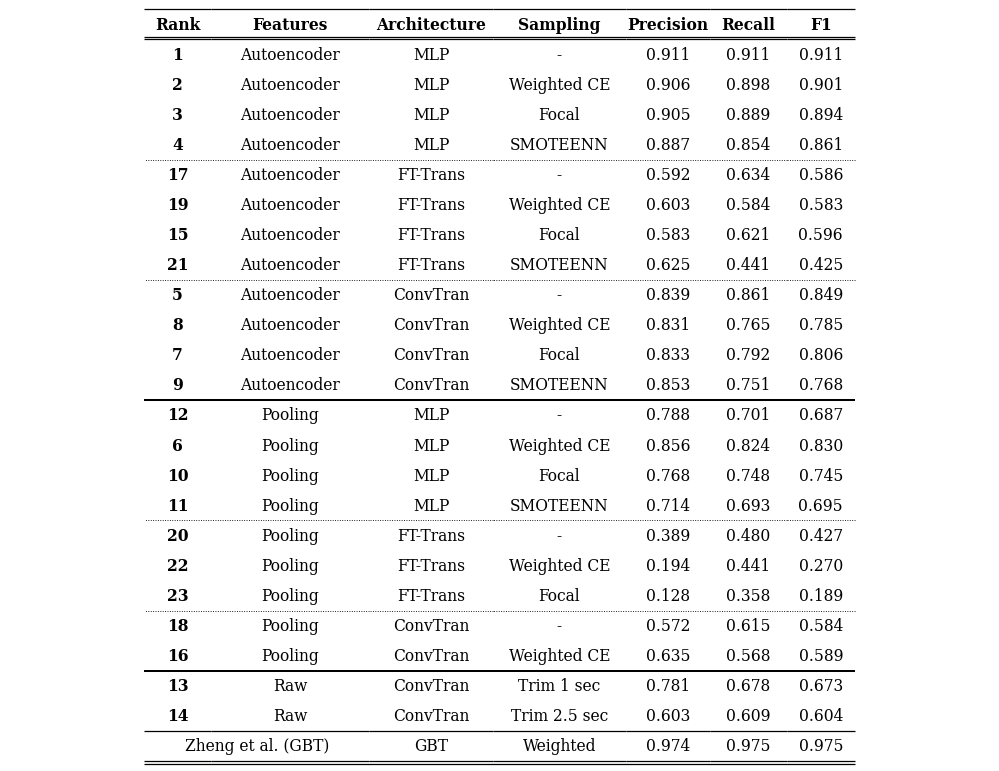

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

df = pd.read_csv(
    r"C:\Projects\DeepLearningProject\plotting\final_full_metrics.csv",
    keep_default_na=False
)

df.columns = df.columns.str.strip()

for col in ["Path", "Architecture", "Sampling"]:
    df[col] = df[col].astype(str).str.strip()

for col in ["Overall P", "Overall R", "Overall F1"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

table_df = df[["Path", "Architecture", "Sampling", "Overall P", "Overall R", "Overall F1"]].copy()

for col in ["Path", "Architecture", "Sampling"]:
    table_df[col] = table_df[col].replace({
        "Trim 5 sec": "Trim 1 sec",
        "Trim 5 seconds": "Trim 1 sec",
        "trim 5 sec": "Trim 1 sec",
        "trim 5 seconds": "Trim 1 sec",
        "Trim 2 sec": "Trim 2.5 sec",
        "Trim 2 seconds": "Trim 2.5 sec",
        "trim 2 sec": "Trim 2.5 sec",
        "trim 2 seconds": "Trim 2.5 sec"
    })

table_df["Architecture"] = table_df["Architecture"].replace({
    "FT-Transformer": "FT-Trans",
    "FT Transformer": "FT-Trans",
    "Conv": "ConvTran",
    "CONVtran": "ConvTran",
    "Convtran": "ConvTran"
})

table_df["Sampling"] = table_df["Sampling"].replace({
    "": "-",
    "None": "-",
    "none": "-",
    "No Sampling": "-",
    "No sampling": "-",
    "WeightedCE": "Weighted CE",
    "Weighted Cross Entropy": "Weighted CE",
    "weightedce": "Weighted CE",
    "weighted_ce": "Weighted CE",
    "weighted ce": "Weighted CE",
    "Focal": "Focal",
    "focal": "Focal",
    "SMOTEENN": "SMOTEENN",
    "smoteenn": "SMOTEENN"
})

table_df["Features"] = table_df["Path"].str.strip().str[0].map({
    "A": "Autoencoder",
    "B": "Pooling"
}).fillna("Raw")

feature_order = {
    "Autoencoder": 0,
    "Pooling": 1,
    "Raw": 2,
    "Zheng et al. (GBT)": 3
}

architecture_order = {
    "MLP": 0,
    "FT-Trans": 1,
    "ConvTran": 2,
    "GBT": 3
}

sampling_order = {
    "-": 0,
    "Weighted CE": 1,
    "Focal": 2,
    "SMOTEENN": 3,
    "Trim 1 sec": 4,
    "Trim 2.5 sec": 5,
    "Weighted": 6
}

table_df["_feature_order"] = table_df["Features"].map(feature_order).fillna(999)
table_df["_architecture_order"] = table_df["Architecture"].map(architecture_order).fillna(999)
table_df["_sampling_order"] = table_df["Sampling"].map(sampling_order).fillna(999)

table_df["Rank"] = (
    table_df["Overall F1"]
    .rank(ascending=False, method="min")
    .astype(int)
    .astype(str)
)

table_df = table_df.sort_values(
    ["_feature_order", "_architecture_order", "_sampling_order", "Overall F1"],
    ascending=[True, True, True, False]
).reset_index(drop=True)

zheng_df = pd.DataFrame({
    "N": [1780, 552, 3889, 1826],
    "Prec": [0.938, 0.953, 0.990, 0.982],
    "Rec": [0.944, 0.944, 0.996, 0.972],
    "F1": [0.941, 0.949, 0.993, 0.977]
})

zheng_weights = zheng_df["N"] / zheng_df["N"].sum()
zheng_p = (zheng_df["Prec"] * zheng_weights).sum()
zheng_r = (zheng_df["Rec"] * zheng_weights).sum()
zheng_f1 = (zheng_df["F1"] * zheng_weights).sum()

zheng_row = pd.DataFrame([{
    "Path": "",
    "Architecture": "GBT",
    "Sampling": "Weighted",
    "Overall P": zheng_p,
    "Overall R": zheng_r,
    "Overall F1": zheng_f1,
    "Features": "Zheng et al. (GBT)",
    "_feature_order": feature_order["Zheng et al. (GBT)"],
    "_architecture_order": architecture_order["GBT"],
    "_sampling_order": sampling_order["Weighted"],
    "Rank": ""
}])

table_df = pd.concat([table_df, zheng_row], ignore_index=True)

display_df = table_df.copy()
for col in ["Overall P", "Overall R", "Overall F1"]:
    display_df[col] = display_df[col].map(lambda x: f"{x:.3f}" if pd.notna(x) else "")

col_labels = ["Rank", "Features", "Architecture", "Sampling", "Precision", "Recall", "F1"]
cell_text = display_df[
    ["Rank", "Features", "Architecture", "Sampling", "Overall P", "Overall R", "Overall F1"]
].values.tolist()

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11.5
})

fig, ax = plt.subplots(figsize=(10.2, 6.05))
ax.axis("off")

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
    colLoc="center",
    colWidths=[0.068, 0.162, 0.126, 0.136, 0.086, 0.078, 0.070]
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11.2)
tbl.scale(1, 1.53)

nrows = len(display_df)
ncols = len(col_labels)

def set_edges(cell, edges="", lw=0.0, linestyle="solid"):
    cell.visible_edges = edges
    cell.set_linewidth(lw)
    cell.set_linestyle(linestyle)

def add_edges(cell, edges, lw, linestyle="solid"):
    current = cell.visible_edges if cell.visible_edges is not None else ""
    merged = ""
    for e in current + edges:
        if e not in merged:
            merged += e
    cell.visible_edges = merged
    cell.set_linewidth(lw)
    cell.set_linestyle(linestyle)

for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor("white")
    cell.set_alpha(1.0)
    cell.set_edgecolor("black")
    set_edges(cell, "", 0.0, "solid")
    cell.set_text_props(weight="normal", color="black")
    cell.PAD = 0.006

for c in range(ncols):
    cell = tbl[(0, c)]
    cell.set_text_props(weight="bold", color="black")
    set_edges(cell, "TB", 0.9, "solid")

for r in range(1, nrows + 1):
    tbl[(r, 0)].set_text_props(weight="bold", color="black")

    for c in [1, 2, 3]:
        tbl[(r, c)]._loc = "left"
        tbl[(r, c)].PAD = 0.008

for i in range(1, nrows):
    cur = table_df.iloc[i]
    prev = table_df.iloc[i - 1]

    if cur["Features"] != prev["Features"]:
        for c in range(ncols):
            add_edges(tbl[(i + 1, c)], "T", 1.45, "solid")
    elif cur["Architecture"] != prev["Architecture"]:
        for c in range(ncols):
            add_edges(tbl[(i + 1, c)], "T", 0.65, "dotted")

for c in range(ncols):
    add_edges(tbl[(nrows, c)], "B", 0.9, "solid")

metric_map = {
    "Overall P": 4,
    "Overall R": 5,
    "Overall F1": 6
}

cmap = LinearSegmentedColormap.from_list(
    "red_yellow_green",
    ["#f4b6b6", "#fff2b2", "#b8e0b8"]
)

for metric_col, table_col_idx in metric_map.items():
    vmin = table_df[metric_col].min()
    vmax = table_df[metric_col].max()

    for r in range(1, nrows + 1):
        value = table_df.iloc[r - 1][metric_col]

        if pd.isna(value):
            continue

        if vmax == vmin:
            t = 0.5
        else:
            t = (value - vmin) / (vmax - vmin)

        cell = tbl[(r, table_col_idx)]
        cell.set_facecolor(cmap(t))
        cell.set_alpha(1.0)
        cell.set_text_props(color="black")

benchmark_rows = display_df.index[display_df["Features"] == "Zheng et al. (GBT)"]
if len(benchmark_rows) > 0:
    zr = benchmark_rows[0] + 1
    tbl[(zr, 0)].get_text().set_text("")
    tbl[(zr, 1)].get_text().set_text("")

fig.canvas.draw()
renderer = fig.canvas.get_renderer()

def disp_to_axes(x_disp, y_disp):
    return ax.transAxes.inverted().transform((x_disp, y_disp))

def draw_hline_at_display_y(y_disp, x0_disp, x1_disp, lw=0.9):
    x0_ax, _ = disp_to_axes(x0_disp, y_disp)
    x1_ax, _ = disp_to_axes(x1_disp, y_disp)
    _, y_ax = disp_to_axes(0, y_disp)
    ax.hlines(
        y_ax,
        x0_ax,
        x1_ax,
        colors="black",
        linewidths=lw,
        transform=ax.transAxes,
        clip_on=False
    )

header_left_bbox = tbl[(0, 0)].get_window_extent(renderer)
header_right_bbox = tbl[(0, ncols - 1)].get_window_extent(renderer)
header_x0 = header_left_bbox.x0
header_x1 = header_right_bbox.x1
header_bottom_y = header_left_bbox.y0

last_left_bbox = tbl[(nrows, 0)].get_window_extent(renderer)
last_right_bbox = tbl[(nrows, ncols - 1)].get_window_extent(renderer)
table_x0 = last_left_bbox.x0
table_x1 = last_right_bbox.x1
table_bottom_y = last_left_bbox.y0

draw_hline_at_display_y(header_bottom_y + 2.2, header_x0, header_x1, lw=0.9)
draw_hline_at_display_y(table_bottom_y - 2.2, table_x0, table_x1, lw=0.9)

if len(benchmark_rows) > 0:
    b0 = tbl[(zr, 0)].get_window_extent(renderer)
    b1 = tbl[(zr, 1)].get_window_extent(renderer)

    x_ax, y_ax = disp_to_axes(
        (min(b0.x0, b1.x0) + max(b0.x1, b1.x1)) / 2,
        (min(b0.y0, b1.y0) + max(b0.y1, b1.y1)) / 2
    )

    ax.text(
        x_ax,
        y_ax,
        "Zheng et al. (GBT)",
        ha="center",
        va="center",
        fontsize=11.2,
        fontfamily="serif",
        fontweight="normal",
        color="black",
        transform=ax.transAxes
    )

plt.subplots_adjust(left=0.02, right=0.98, top=0.968, bottom=0.06)

plt.savefig(
    r"C:\Projects\DeepLearningProject\plotting\poster_overall_table_bw_ranked.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.012
)

plt.show()

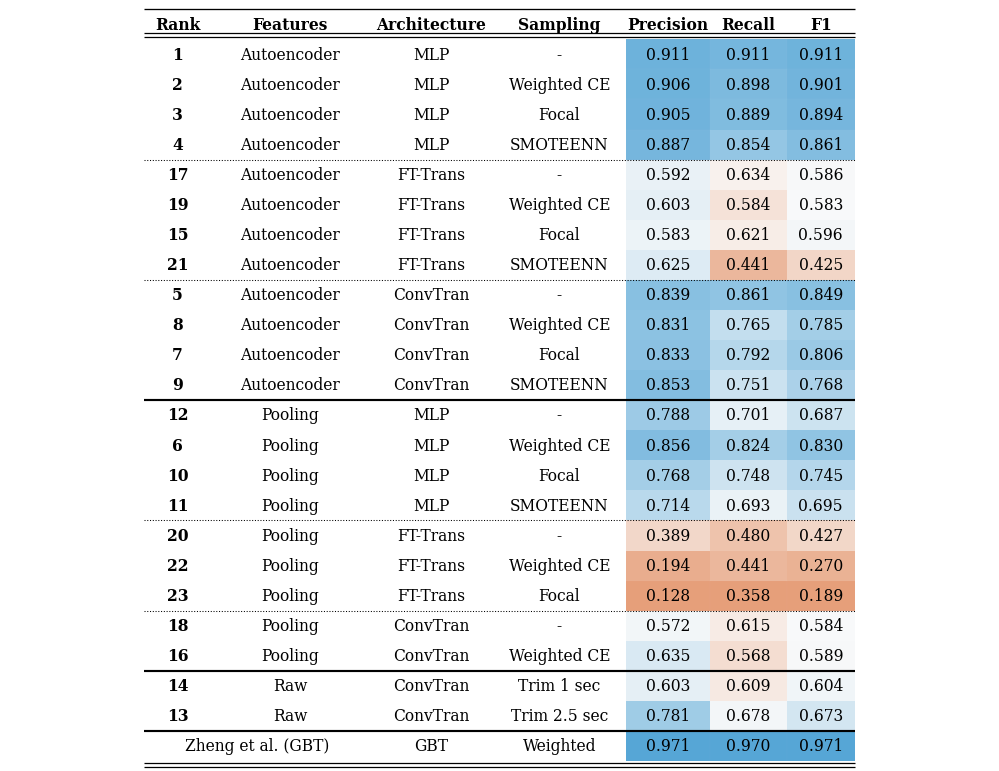

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

df = pd.read_csv(
    r"C:\Projects\DeepLearningProject\plotting\final_full_metrics.csv",
    keep_default_na=False
)

df.columns = df.columns.str.strip()

for col in ["Path", "Architecture", "Sampling"]:
    df[col] = df[col].astype(str).str.strip()

for col in ["Overall P", "Overall R", "Overall F1"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

table_df = df[["Path", "Architecture", "Sampling", "Overall P", "Overall R", "Overall F1"]].copy()

for col in ["Path", "Architecture", "Sampling"]:
    table_df[col] = table_df[col].replace({
        "Trim 5 sec": "Trim 2.5 sec",
        "Trim 5 seconds": "Trim 2.5 sec",
        "trim 5 sec": "Trim 2.5 sec",
        "trim 5 seconds": "Trim 2.5 sec",

        "Trim 2 sec": "Trim 1 sec",
        "Trim 2 seconds": "Trim 1 sec",
        "trim 2 sec": "Trim 1 sec",
        "trim 2 seconds": "Trim 1 sec"
    })

table_df["Architecture"] = table_df["Architecture"].replace({
    "FT-Transformer": "FT-Trans",
    "FT Transformer": "FT-Trans",
    "Conv": "ConvTran",
    "CONVtran": "ConvTran",
    "Convtran": "ConvTran"
})

table_df["Sampling"] = table_df["Sampling"].replace({
    "": "-",
    "None": "-",
    "none": "-",
    "No Sampling": "-",
    "No sampling": "-",
    "WeightedCE": "Weighted CE",
    "Weighted Cross Entropy": "Weighted CE",
    "weightedce": "Weighted CE",
    "weighted_ce": "Weighted CE",
    "weighted ce": "Weighted CE",
    "Focal": "Focal",
    "focal": "Focal",
    "SMOTEENN": "SMOTEENN",
    "smoteenn": "SMOTEENN"
})

table_df["Features"] = table_df["Path"].str.strip().str[0].map({
    "A": "Autoencoder",
    "B": "Pooling"
}).fillna("Raw")

feature_order = {
    "Autoencoder": 0,
    "Pooling": 1,
    "Raw": 2,
    "Zheng et al. (GBT)": 3
}

architecture_order = {
    "MLP": 0,
    "FT-Trans": 1,
    "ConvTran": 2,
    "GBT": 3
}

sampling_order = {
    "-": 0,
    "Weighted CE": 1,
    "Focal": 2,
    "SMOTEENN": 3,
    "Trim 1 sec": 4,
    "Trim 2.5 sec": 5,
    "Weighted": 6
}

table_df["_feature_order"] = table_df["Features"].map(feature_order).fillna(999)
table_df["_architecture_order"] = table_df["Architecture"].map(architecture_order).fillna(999)
table_df["_sampling_order"] = table_df["Sampling"].map(sampling_order).fillna(999)

table_df["Rank"] = (
    table_df["Overall F1"]
    .rank(ascending=False, method="min")
    .astype(int)
    .astype(str)
)

table_df = table_df.sort_values(
    ["_feature_order", "_architecture_order", "_sampling_order", "Overall F1"],
    ascending=[True, True, True, False]
).reset_index(drop=True)

zheng_df = pd.DataFrame({
    "N": [8753, 6913, 15528, 9064],
    "Prec": [0.938, 0.953, 0.990, 0.982],
    "Rec": [0.944, 0.944, 0.996, 0.972],
    "F1": [0.941, 0.949, 0.993, 0.977]
})

zheng_weights = zheng_df["N"] / zheng_df["N"].sum()
zheng_p = (zheng_df["Prec"] * zheng_weights).sum()
zheng_r = (zheng_df["Rec"] * zheng_weights).sum()
zheng_f1 = (zheng_df["F1"] * zheng_weights).sum()

zheng_row = pd.DataFrame([{
    "Path": "",
    "Architecture": "GBT",
    "Sampling": "Weighted",
    "Overall P": zheng_p,
    "Overall R": zheng_r,
    "Overall F1": zheng_f1,
    "Features": "Zheng et al. (GBT)",
    "_feature_order": feature_order["Zheng et al. (GBT)"],
    "_architecture_order": architecture_order["GBT"],
    "_sampling_order": sampling_order["Weighted"],
    "Rank": ""
}])

table_df = pd.concat([table_df, zheng_row], ignore_index=True)

display_df = table_df.copy()

for col in ["Overall P", "Overall R", "Overall F1"]:
    display_df[col] = display_df[col].map(lambda x: f"{x:.3f}" if pd.notna(x) else "")

col_labels = ["Rank", "Features", "Architecture", "Sampling", "Precision", "Recall", "F1"]
cell_text = display_df[
    ["Rank", "Features", "Architecture", "Sampling", "Overall P", "Overall R", "Overall F1"]
].values.tolist()

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11.5
})

fig, ax = plt.subplots(figsize=(10.2, 6.05))
ax.axis("off")

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
    colLoc="center",
    colWidths=[0.068, 0.162, 0.126, 0.136, 0.086, 0.078, 0.070]
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11.2)
tbl.scale(1, 1.53)

nrows = len(display_df)
ncols = len(col_labels)

metric_map = {
    "Overall P": col_labels.index("Precision"),
    "Overall R": col_labels.index("Recall"),
    "Overall F1": col_labels.index("F1")
}

cmap = LinearSegmentedColormap.from_list(
    "soft_vermilion_white_blue",
    ["#E69F7A", "#FAFAFA", "#56A6D6"]
)

for (r, c), cell in tbl.get_celld().items():
    cell.visible_edges = "closed"
    cell.set_linewidth(0.01)
    cell.set_edgecolor((1, 1, 1, 0))
    cell.set_facecolor("white")
    cell.set_alpha(1.0)
    cell.set_text_props(weight="normal", color="black")
    cell.PAD = 0.006

for metric_col, table_col_idx in metric_map.items():
    vmin = table_df[metric_col].min()
    vmax = table_df[metric_col].max()

    for r in range(1, nrows + 1):
        value = table_df.iloc[r - 1][metric_col]

        if pd.isna(value):
            continue

        t = 0.5 if vmax == vmin else (value - vmin) / (vmax - vmin)
        tbl[(r, table_col_idx)].set_facecolor(cmap(t))
        tbl[(r, table_col_idx)].set_alpha(1.0)

for c in range(ncols):
    tbl[(0, c)].set_text_props(weight="bold", color="black")

for r in range(1, nrows + 1):
    tbl[(r, 0)].set_text_props(weight="bold", color="black")

    for c in [1, 2, 3]:
        tbl[(r, c)]._loc = "left"
        tbl[(r, c)].PAD = 0.008

benchmark_rows = display_df.index[display_df["Features"] == "Zheng et al. (GBT)"]
if len(benchmark_rows) > 0:
    zr = benchmark_rows[0] + 1
    tbl[(zr, 0)].get_text().set_text("")
    tbl[(zr, 1)].get_text().set_text("")

fig.canvas.draw()
renderer = fig.canvas.get_renderer()

def disp_to_axes(x_disp, y_disp):
    return ax.transAxes.inverted().transform((x_disp, y_disp))

def draw_hline(y_disp, x0_disp, x1_disp, lw=1.0, linestyle="solid"):
    x0_ax, _ = disp_to_axes(x0_disp, y_disp)
    x1_ax, _ = disp_to_axes(x1_disp, y_disp)
    _, y_ax = disp_to_axes(0, y_disp)

    ax.hlines(
        y_ax,
        x0_ax,
        x1_ax,
        colors="black",
        linewidths=lw,
        linestyles=linestyle,
        transform=ax.transAxes,
        clip_on=False,
        zorder=10
    )

header_left_bbox = tbl[(0, 0)].get_window_extent(renderer)
header_right_bbox = tbl[(0, ncols - 1)].get_window_extent(renderer)
header_x0 = header_left_bbox.x0
header_x1 = header_right_bbox.x1
header_top_y = header_left_bbox.y1
header_bottom_y = header_left_bbox.y0

last_left_bbox = tbl[(nrows, 0)].get_window_extent(renderer)
last_right_bbox = tbl[(nrows, ncols - 1)].get_window_extent(renderer)
table_x0 = last_left_bbox.x0
table_x1 = last_right_bbox.x1
table_bottom_y = last_left_bbox.y0

draw_hline(header_top_y, header_x0, header_x1, lw=0.95)
draw_hline(header_bottom_y + 5.0, header_x0, header_x1, lw=0.9)
draw_hline(header_bottom_y + 1.8, header_x0, header_x1, lw=0.9)

for i in range(1, nrows):
    cur = table_df.iloc[i]
    prev = table_df.iloc[i - 1]

    row_bbox = tbl[(i + 1, 0)].get_window_extent(renderer)
    y = row_bbox.y1

    if cur["Features"] != prev["Features"]:
        draw_hline(y, table_x0, table_x1, lw=1.55, linestyle="solid")
    elif cur["Architecture"] != prev["Architecture"]:
        draw_hline(y, table_x0, table_x1, lw=0.75, linestyle="dotted")

draw_hline(table_bottom_y - 1.8, table_x0, table_x1, lw=0.9)
draw_hline(table_bottom_y - 5.0, table_x0, table_x1, lw=0.9)

if len(benchmark_rows) > 0:
    b0 = tbl[(zr, 0)].get_window_extent(renderer)
    b1 = tbl[(zr, 1)].get_window_extent(renderer)

    x_ax, y_ax = disp_to_axes(
        (min(b0.x0, b1.x0) + max(b0.x1, b1.x1)) / 2,
        (min(b0.y0, b1.y0) + max(b0.y1, b1.y1)) / 2
    )

    ax.text(
        x_ax,
        y_ax,
        "Zheng et al. (GBT)",
        ha="center",
        va="center",
        fontsize=11.2,
        fontfamily="serif",
        fontweight="normal",
        color="black",
        transform=ax.transAxes,
        zorder=20
    )

plt.subplots_adjust(left=0.02, right=0.98, top=0.968, bottom=0.06)

plt.savefig(
    r"C:\Projects\DeepLearningProject\plotting\poster_overall_table_bw_ranked.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.012
)

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

csv_path = Path("merged_results_with_raw_convtran.csv")
out_png = Path("appendix_full_results_table.png")
out_pdf = Path("appendix_full_results_table.pdf")

df = pd.read_csv(csv_path, keep_default_na=False)
df.columns = df.columns.str.strip()

df["Features"] = df["Features"].astype(str).str.strip()
df["Architecture"] = df["Architecture"].astype(str).str.strip()
df["Sampling"] = df["Sampling"].astype(str).str.strip()

df["Architecture"] = df["Architecture"].replace({
    "FT-Transformer": "FT-Trans",
    "FT Transformer": "FT-Trans",
    "Convtransformer": "ConvTran",
    "ConvTransformer": "ConvTran",
    "Convtran": "ConvTran",
    "CONVtran": "ConvTran"
})

df["Sampling"] = df["Sampling"].replace({
    "": "-",
    "None": "-",
    "none": "-",
    "No Sampling": "-",
    "No sampling": "-",
    "WeightedCE": "Weighted CE",
    "weightedce": "Weighted CE",
    "weighted_ce": "Weighted CE",
    "weighted ce": "Weighted CE",
    "Weighted Cross Entropy": "Weighted CE",
    "Weighted Cross-Entropy": "Weighted CE",
    "Class Balanced Focal Loss": "Focal",
    "Focal Loss": "Focal",
    "focal": "Focal",
    "Raw 1 sec": "Raw 1 s",
    "Raw 2.5 sec": "Raw 2.5 s",
    "Weighted": "Weighted"
})

feature_order = {
    "Autoencoder": 0,
    "Structured Pooling": 1,
    "Raw ECG": 2,
    "Zheng et al. (GBT)": 3
}

architecture_order = {
    "MLP": 0,
    "FT-Trans": 1,
    "ConvTran": 2,
    "GBT": 3
}

strategy_order = {
    "-": 0,
    "Weighted CE": 1,
    "Focal": 2,
    "SMOTEENN": 3,
    "Raw 1 s": 4,
    "Raw 2.5 s": 5,
    "Weighted": 6
}

df["_feature_order"] = df["Features"].map(feature_order).fillna(999)
df["_architecture_order"] = df["Architecture"].map(architecture_order).fillna(999)
df["_strategy_order"] = df["Sampling"].map(strategy_order).fillna(999)

metric_cols = [
    "Overall P", "Overall R", "Overall F1",
    "Macro P", "Macro R", "Macro F1",
    "AF P", "AF R", "AF F1",
    "SVT P", "SVT R", "SVT F1",
    "Sinus Brady P", "Sinus Brady R", "Sinus Brady F1",
    "Sinus Rhythm P", "Sinus Rhythm R", "Sinus Rhythm F1"
]

for col in metric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

if "Rank" in df.columns:
    rank_values = pd.to_numeric(df["Rank"], errors="coerce")
else:
    rank_values = pd.Series(index=df.index, dtype=float)

missing_rank = rank_values.isna()
if missing_rank.any():
    rank_values.loc[missing_rank] = (
        df.loc[missing_rank, "Overall F1"]
        .rank(ascending=False, method="min")
    )

df["Rank"] = rank_values.astype(int).astype(str)

df = df.sort_values(
    ["_feature_order", "_architecture_order", "_strategy_order", "Overall F1"],
    ascending=[True, True, True, False]
).reset_index(drop=True)

display_cols = [
    "Rank", "Features", "Architecture", "Sampling",
    "Overall P", "Overall R", "Overall F1",
    "Macro P", "Macro R", "Macro F1",
    "AF P", "AF R", "AF F1",
    "SVT P", "SVT R", "SVT F1",
    "Sinus Brady P", "Sinus Brady R", "Sinus Brady F1",
    "Sinus Rhythm P", "Sinus Rhythm R", "Sinus Rhythm F1"
]

display_df = df[display_cols].copy()

for col in metric_cols:
    display_df[col] = display_df[col].map(lambda x: f"{x:.3f}" if pd.notna(x) else "")

col_labels = [
    "Rank", "Feature Group", "Architecture", "Strategy",
    "P", "R", "F1",
    "P", "R", "F1",
    "P", "R", "F1",
    "P", "R", "F1",
    "P", "R", "F1",
    "P", "R", "F1"
]

cell_text = display_df.values.tolist()

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10
})

fig, ax = plt.subplots(figsize=(26, 10))
ax.axis("off")

col_widths = [
    0.04, 0.12, 0.08, 0.08,
    0.045, 0.045, 0.05,
    0.045, 0.045, 0.05,
    0.04, 0.04, 0.045,
    0.04, 0.04, 0.045,
    0.055, 0.055, 0.06,
    0.055, 0.055, 0.06
]

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=col_widths
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9.3)
tbl.scale(1, 1.55)

cmap = LinearSegmentedColormap.from_list(
    "soft_vwb",
    ["#E8A07C", "#FAFAFA", "#67A9CF"]
)

for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor("white")
    cell.set_edgecolor((1, 1, 1, 0))
    cell.set_linewidth(0)
    cell.PAD = 0.008
    cell.set_text_props(color="black", weight="normal")

nrows = len(display_df)
ncols = len(col_labels)

for c in range(ncols):
    tbl[(0, c)].set_text_props(weight="bold")
    tbl[(0, c)].PAD = 0.012

for r in range(1, nrows + 1):
    tbl[(r, 0)].set_text_props(weight="bold")
    for c in [1, 2, 3]:
        tbl[(r, c)]._loc = "left"
        tbl[(r, c)].PAD = 0.010

for col_name in metric_cols:
    values = pd.to_numeric(df[col_name], errors="coerce")
    vmin = values.min()
    vmax = values.max()
    table_col_idx = display_cols.index(col_name)

    for r in range(1, nrows + 1):
        val = values.iloc[r - 1]
        if pd.isna(val):
            continue
        t = 0.5 if vmax == vmin else (val - vmin) / (vmax - vmin)
        tbl[(r, table_col_idx)].set_facecolor(cmap(t))

fig.canvas.draw()
renderer = fig.canvas.get_renderer()

def disp_to_axes(x_disp, y_disp):
    return ax.transAxes.inverted().transform((x_disp, y_disp))

def draw_hline(y_disp, x0_disp, x1_disp, lw=1.0, linestyle="solid"):
    x0_ax, _ = disp_to_axes(x0_disp, y_disp)
    x1_ax, _ = disp_to_axes(x1_disp, y_disp)
    _, y_ax = disp_to_axes(0, y_disp)
    ax.hlines(
        y_ax, x0_ax, x1_ax,
        colors="black",
        linewidths=lw,
        linestyles=linestyle,
        transform=ax.transAxes,
        clip_on=False,
        zorder=20
    )

def add_group_title(label, start_col, end_col, y_disp, fontsize=10.5):
    left_bbox = tbl[(0, start_col)].get_window_extent(renderer)
    right_bbox = tbl[(0, end_col)].get_window_extent(renderer)
    x_center_disp = (left_bbox.x0 + right_bbox.x1) / 2
    x_ax, y_ax = disp_to_axes(x_center_disp, y_disp)
    ax.text(
        x_ax, y_ax, label,
        ha="center", va="center",
        fontsize=fontsize,
        fontweight="bold",
        fontfamily="serif",
        transform=ax.transAxes,
        zorder=25
    )

header_left_bbox = tbl[(0, 0)].get_window_extent(renderer)
header_right_bbox = tbl[(0, ncols - 1)].get_window_extent(renderer)
header_x0 = header_left_bbox.x0
header_x1 = header_right_bbox.x1
header_top_y = header_left_bbox.y1
header_bottom_y = header_left_bbox.y0

table_bottom_bbox = tbl[(nrows, 0)].get_window_extent(renderer)
table_bottom_y = table_bottom_bbox.y0

group_y = header_top_y + 16

draw_hline(group_y + 9, header_x0, header_x1, lw=1.1)
draw_hline(header_top_y, header_x0, header_x1, lw=0.9)
draw_hline(header_bottom_y + 5, header_x0, header_x1, lw=0.9)
draw_hline(header_bottom_y + 1.6, header_x0, header_x1, lw=0.9)

add_group_title("Weighted Overall", 4, 6, group_y)
add_group_title("Macro Overall", 7, 9, group_y)
add_group_title("AF", 10, 12, group_y)
add_group_title("SVT", 13, 15, group_y)
add_group_title("Sinus Brady", 16, 18, group_y)
add_group_title("Sinus Rhythm", 19, 21, group_y)

for i in range(1, nrows):
    cur = df.iloc[i]
    prev = df.iloc[i - 1]
    row_bbox = tbl[(i + 1, 0)].get_window_extent(renderer)
    y = row_bbox.y1

    if cur["Features"] != prev["Features"]:
        draw_hline(y, header_x0, header_x1, lw=1.45, linestyle="solid")
    elif cur["Architecture"] != prev["Architecture"]:
        draw_hline(y, header_x0, header_x1, lw=0.75, linestyle="dotted")

draw_hline(table_bottom_y - 2.0, header_x0, header_x1, lw=0.9)
draw_hline(table_bottom_y - 5.0, header_x0, header_x1, lw=0.9)

plt.subplots_adjust(left=0.01, right=0.99, top=0.92, bottom=0.03)

plt.savefig(out_png, dpi=600, bbox_inches="tight", pad_inches=0.02)
plt.savefig(out_pdf, bbox_inches="tight", pad_inches=0.02)

FileNotFoundError: [Errno 2] No such file or directory: '\\mnt\\data\\merged_results_with_raw_convtran.csv'